# Sample Portfolio — Equal Weight with Monthly Rebalancing

This notebook models what a basic robo-advisor actually does in practice:
assign a simple equal-weight portfolio and rebalance it back to target every month.

This is different from the static equal-weight baseline used in other notebooks.
The static version sets weights once and never touches them.
This version actively rebalances, trimming assets that grew too large
and topping up assets that fell behind, every single month.

That one difference ------ rebalancing vs not ----- is what we are isolating here.

Assets: `BND, GLD, TIP, TLT, VEU, VGT`

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

with open("../../markets.json") as f:
    config = json.load(f)

BASE = Path("../../data")
name = list(config["markets"].keys())[0]

In [ ]:
# Load rolling risk-free rate from FRED TB3MS series (generated by 01_main.ipynb)
_rf_file = BASE / "risk_free_monthly.csv"
if _rf_file.exists():
    _rf_data           = pd.read_csv(_rf_file, index_col=0, parse_dates=True)
    _annual_rf_series  = _rf_data["rf_annual"]
    _monthly_rf_series = _rf_data["rf_monthly"]
    RISK_FREE_ANNUAL   = _annual_rf_series.mean()
    RISK_FREE_MONTHLY  = _monthly_rf_series.mean()
    print(f"RF loaded  : {RISK_FREE_ANNUAL*100:.3f}% annual (placeholder — re-aligned in Cell 10)")
else:
    print("WARNING: risk_free_monthly.csv not found. Run 01_main.ipynb first.")
    RISK_FREE_ANNUAL   = 0.0162
    RISK_FREE_MONTHLY  = (1 + RISK_FREE_ANNUAL) ** (1/12) - 1
    _annual_rf_series  = None
    _monthly_rf_series = None

CRISES = [
    ("2008-09", "2009-06", "GFC"),
    ("2020-02", "2020-04", "COVID"),
    ("2022-01", "2022-12", "Rate Hikes"),
]

PALETTE = ["#028090", "#F6C90E", "#E53E3E", "#38A169", "#6B46C1", "#C05621"]
plt.rcParams.update({
    "figure.facecolor" : "#F4F7FB",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.4,
    "grid.color"       : "#CBD5E0",
    "font.family"      : "sans-serif",
})

print(f"Market    : {name}")
print(f"Risk-free : {RISK_FREE_ANNUAL*100:.2f}% annual")

RF loaded  : 1.640% annual (placeholder — re-aligned in Cell 9)
Market    : primary_total_market
Risk-free : 1.64% annual


In [ ]:
rets = pd.read_csv(
    BASE / f"{name}_returns_monthly.csv",
    index_col=0, parse_dates=True
)

ASSETS = list(rets.columns)
N      = len(ASSETS)
TARGET = 1.0 / N   # equal weight target = 1/6 per asset
BASE_GROWTH_DOLLARS = 1000


print(f"Period    : {rets.index[0].date()} -> {rets.index[-1].date()}")
print(f"Assets    : {ASSETS}")
print(f"Target wt : {TARGET:.4f} ({TARGET*100:.2f}%) per asset")

Period    : 2007-05-01 -> 2025-12-01
Assets    : ['BND', 'GLD', 'TIP', 'TLT', 'VEU', 'VGT']
Target wt : 0.1667 (16.67%) per asset


## 1. How Rebalancing Works

In [4]:
# Monthly Rebalancing Simulation 

# Each month:
#   1. Start with current weights (drifted from last month's returns)
#   2. Earn this month's return
#   3. Rebalance back to 1/N for every asset
#   4. Record the portfolio return for this month

# The turnover each month = total weight that had to be traded
# to restore the equal-weight target.

# Start at equal weight
current_weights = np.ones(N) / N

portfolio_returns = []
weight_history    = []   # weights at START of each month (before that month return)
turnover_history  = []   # weight traded when rebalancing at END of each month

for date, row in rets.iterrows():
    monthly_ret = row.values

    # Step 1: Record weights held at start of this month
    weight_history.append(current_weights.copy())

    # Step 2: Earn this month return using current (possibly drifted) weights
    new_values  = current_weights * (1 + monthly_ret)
    port_return = new_values.sum() - 1
    portfolio_returns.append(port_return)

    # Step 3: Weights have now drifted due to different asset returns
    drifted_weights = new_values / new_values.sum()

    # Step 4: Rebalance back to 1/N AFTER earning the return
    target_weights = np.ones(N) / N
    turnover       = np.abs(drifted_weights - target_weights).sum()
    turnover_history.append(turnover)

    # Step 5: Next month starts at equal weight (post-rebalance)
    current_weights = target_weights

# Package results
sample_ret    = pd.Series(portfolio_returns, index=rets.index)
weight_df     = pd.DataFrame(weight_history, index=rets.index, columns=ASSETS)
turnover_s    = pd.Series(turnover_history,  index=rets.index)

# Static equal weight (no rebalancing) — for comparison
static_ret = (rets * (1/N)).sum(axis=1)

print(f"Months simulated   : {len(sample_ret)}")
print(f"Avg monthly turnover: {turnover_s.mean()*100:.2f}%")
print(f"Max monthly turnover: {turnover_s.max()*100:.2f}%")

Months simulated   : 224
Avg monthly turnover: 2.47%
Max monthly turnover: 8.30%


## 2. Weight Drift Without Rebalancing

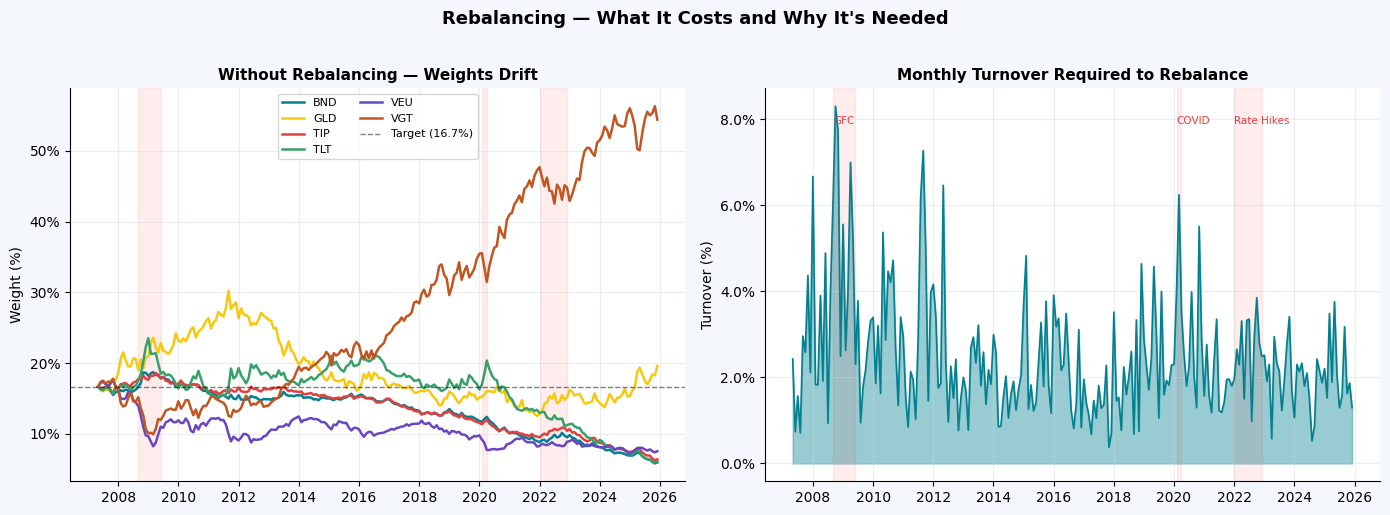

In [5]:
# Show How Weights Drift Without Rebalancing 

# Without rebalancing, high-performing assets take over the portfolio.
# This chart shows what happens to weights if you never rebalance.
# It explains WHY rebalancing matters for maintaining the intended allocation.

# Simulate drifting weights (no rebalancing)
drift_w = np.ones(N) / N
drift_history = []

for _, row in rets.iterrows():
    drift_history.append(drift_w.copy())
    new_vals = drift_w * (1 + row.values)
    drift_w  = new_vals / new_vals.sum()

drift_df = pd.DataFrame(drift_history, index=rets.index, columns=ASSETS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: drifting weights
ax = axes[0]
for asset, color in zip(ASSETS, PALETTE):
    ax.plot(drift_df[asset] * 100, label=asset, color=color, linewidth=1.8)
ax.axhline(100/N, color="black", linewidth=1, linestyle="--", alpha=0.5,
           label=f"Target ({100/N:.1f}%)")
for start, end, label in CRISES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.07, color="red")
ax.set_title("Without Rebalancing — Weights Drift",
             fontweight="bold", fontsize=11)
ax.set_ylabel("Weight (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=8, ncol=2)

# Right: monthly turnover needed to maintain equal weight
ax = axes[1]
ax.fill_between(turnover_s.index, turnover_s * 100, alpha=0.4, color="#028090")
ax.plot(turnover_s * 100, color="#028090", linewidth=1.2)
for start, end, label in CRISES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.07, color="red")
    ax.text(pd.Timestamp(start), turnover_s.max()*95,
            label, fontsize=7.5, color="#E53E3E")
ax.set_title("Monthly Turnover Required to Rebalance",
             fontweight="bold", fontsize=11)
ax.set_ylabel("Turnover (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

fig.suptitle("Rebalancing — What It Costs and Why It's Needed",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3. Cumulative Performance

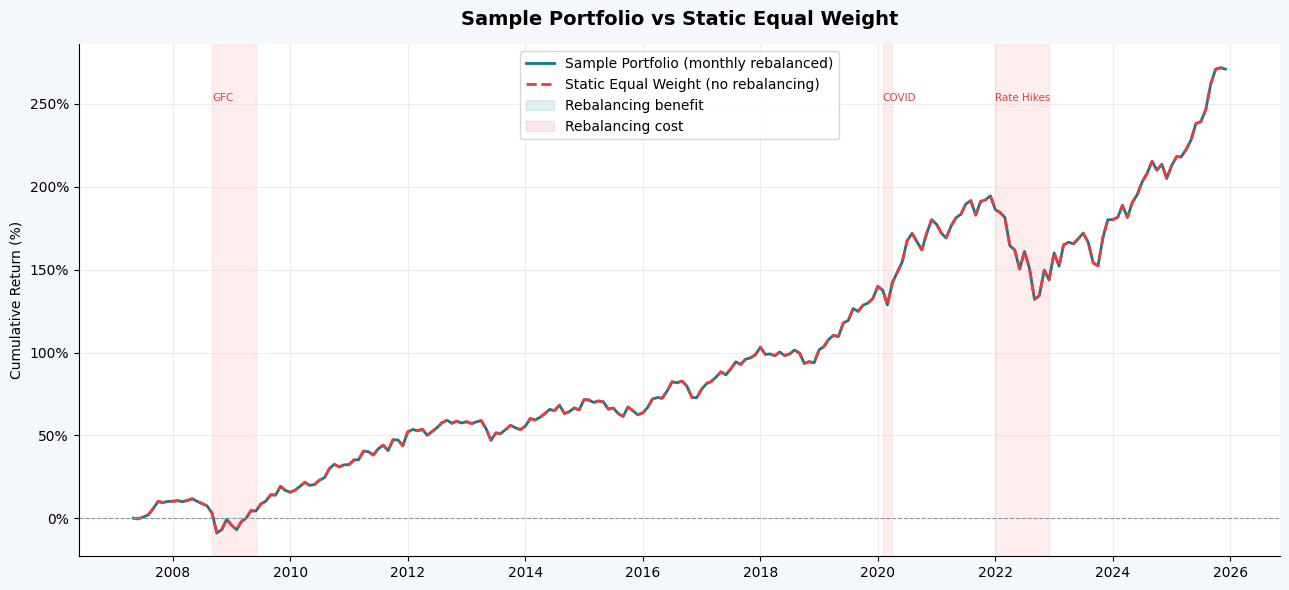

In [6]:
# Cumulative Performance 
# Sample Portfolio (rebalanced) vs Static Equal Weight (never rebalanced).
# The gap between these two lines is the pure effect of rebalancing.

sample_growth = ((1 + sample_ret).cumprod() - 1) * 100
static_growth = ((1 + static_ret).cumprod() - 1) * 100

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(sample_growth, color="#028090", linewidth=2,
        label="Sample Portfolio (monthly rebalanced)")
ax.plot(static_growth, color="#E53E3E", linewidth=2, linestyle="--",
        label="Static Equal Weight (no rebalancing)")

ax.fill_between(sample_growth.index,
                sample_growth, static_growth,
                where=(sample_growth >= static_growth),
                alpha=0.12, color="#028090",
                label="Rebalancing benefit")
ax.fill_between(sample_growth.index,
                sample_growth, static_growth,
                where=(sample_growth < static_growth),
                alpha=0.12, color="#E53E3E",
                label="Rebalancing cost")

for start, end, label in CRISES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.07, color="red")
ymax = ax.get_ylim()[1]
for start, _, label in CRISES:
    ax.text(pd.Timestamp(start), ymax * 0.88, label,
            fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8, linestyle="--")
ax.set_title("Sample Portfolio vs Static Equal Weight",
             fontsize=14, fontweight="bold", pad=14)
ax.set_ylabel("Cumulative Return (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

look the chart above:

- rebalancing didn't meaningfully improve or hurt returns over this period
- The two lines converge and diverge by small amounts throughout
- supports the Brinson et al. thesis that allocation policy dominates, not the rebalancing mechanism itself

## 4. Drawdown Paths

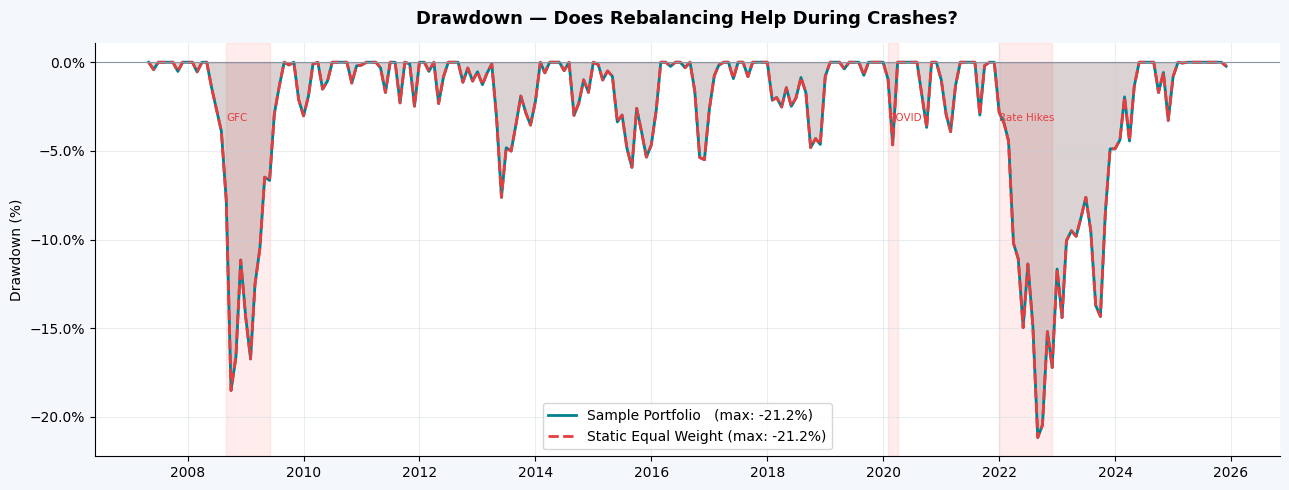

In [7]:
# Drawdown Paths 

# Does rebalancing help during crashes?
# Rebalancing forces buying into falling assets — this can deepen short-term
# drawdowns but also speeds up recovery once markets stabilise.

def drawdown(ret_series):
    cum = (1 + ret_series).cumprod()
    return ((cum - cum.cummax()) / cum.cummax()) * 100

dd_sample = drawdown(sample_ret)
dd_static = drawdown(static_ret)

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(dd_sample.index, dd_sample, 0, alpha=0.15, color="#028090")
ax.fill_between(dd_static.index, dd_static, 0, alpha=0.15, color="#E53E3E")

ax.plot(dd_sample, color="#028090", linewidth=2,
        label=f"Sample Portfolio   (max: {dd_sample.min():.1f}%)")
ax.plot(dd_static, color="#E53E3E", linewidth=2, linestyle="--",
        label=f"Static Equal Weight (max: {dd_static.min():.1f}%)")

for start, end, label in CRISES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.07, color="red")
ymin = ax.get_ylim()[0]
for start, _, label in CRISES:
    ax.text(pd.Timestamp(start), ymin * 0.15, label,
            fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8)
ax.set_title("Drawdown — Does Rebalancing Help During Crashes?",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 5. Volatility Exposure Over Time

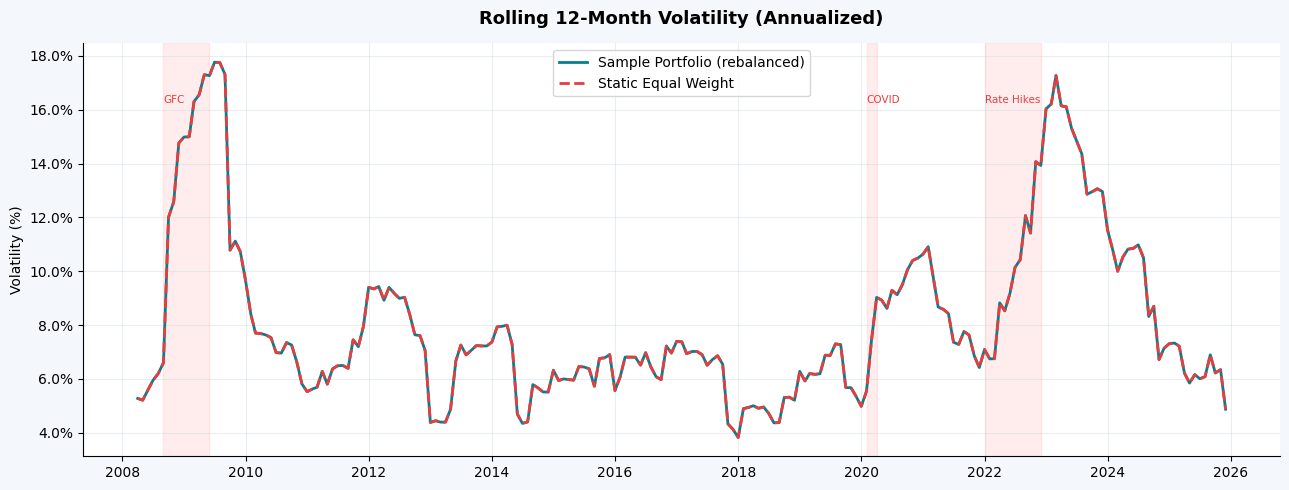

In [8]:
# Rolling Volatility 

# Rolling 12-month annualized volatility for both portfolios.
# Rebalancing keeps volatility more stable because it prevents
# high-vol assets from growing too large over time.

ROLL = 12   # 12-month rolling window

roll_vol_sample = sample_ret.rolling(ROLL).std() * np.sqrt(12) * 100
roll_vol_static = static_ret.rolling(ROLL).std() * np.sqrt(12) * 100

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(roll_vol_sample, color="#028090", linewidth=2,
        label="Sample Portfolio (rebalanced)")
ax.plot(roll_vol_static, color="#E53E3E", linewidth=2, linestyle="--",
        label="Static Equal Weight")

for start, end, label in CRISES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.07, color="red")
ymax = ax.get_ylim()[1]
for start, _, label in CRISES:
    ax.text(pd.Timestamp(start), ymax * 0.88, label,
            fontsize=7.5, color="#E53E3E")

ax.set_title(f"Rolling {ROLL}-Month Volatility (Annualized)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Volatility (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 6. Recovery Dynamics

In [9]:
# Recovery Dynamics 
# How long did each portfolio take to recover from each crisis?
# Recovery = first month the portfolio returned to its pre-crash peak.

def months_to_recover(ret_series, crisis_start, crisis_end):
    """
    Returns number of months from the drawdown trough to full recovery.
    Returns None if not yet recovered by end of data.
    """
    cum         = (1 + ret_series).cumprod()
    # Peak just before crisis
    pre_crisis  = cum.loc[:crisis_start]
    if pre_crisis.empty:
        return None
    peak_val    = pre_crisis.max()
    # Find trough during crisis
    during      = cum.loc[crisis_start:crisis_end]
    if during.empty:
        return None
    trough_date = during.idxmin()
    # Find first date after trough where portfolio exceeds pre-crisis peak
    after       = cum.loc[trough_date:]
    recovered   = after[after >= peak_val]
    if recovered.empty:
        return None
    recovery_date = recovered.index[0]
    months        = len(cum.loc[trough_date:recovery_date]) - 1
    return months

print("── Recovery Time (months from trough to new peak) ──")
print(f"{'Crisis':<18} {'Sample Portfolio':>20} {'Static Equal Wt':>18}")
print("-" * 58)

for start, end, label in CRISES:
    m_sample = months_to_recover(sample_ret, start, end)
    m_static = months_to_recover(static_ret, start, end)
    s_str = f"{m_sample} months" if m_sample is not None else "Not recovered"
    t_str = f"{m_static} months" if m_static is not None else "Not recovered"
    print(f"{label:<18} {s_str:>20} {t_str:>18}")

── Recovery Time (months from trough to new peak) ──
Crisis                 Sample Portfolio    Static Equal Wt
----------------------------------------------------------
GFC                           11 months          11 months
COVID                          1 months           1 months
Rate Hikes                    21 months          21 months


## 7. Performance Summary

RF (aligned to data period): 1.415% annual  <- used for Sharpe
── Performance Summary ──
                     Ann. Return %  Ann. Vol %  Sharpe Ratio  Max Drawdown %  Final Value ($)  Avg Turnover %
Sample Portfolio              7.42        8.64         0.698          -21.17             3.71            2.47
Static Equal Weight           7.42        8.64         0.698          -21.17             3.71            0.00


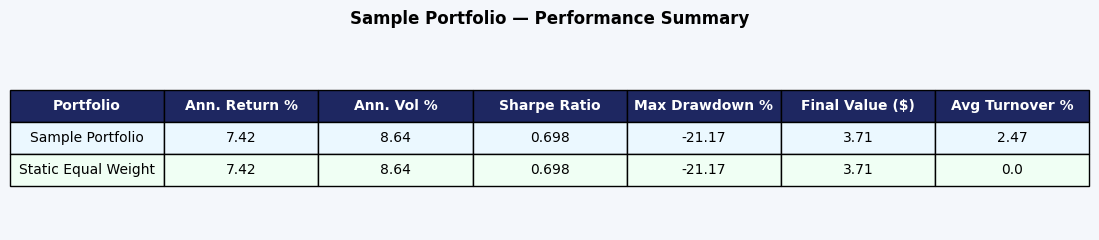

In [11]:
# Performance Summary 


# Re-align RF scalar to data period — single source of truth for Sharpe
if _annual_rf_series is not None:
    RISK_FREE_ANNUAL  = _annual_rf_series.reindex(rets.index, method="ffill").mean()
    RISK_FREE_MONTHLY = _monthly_rf_series.reindex(rets.index, method="ffill").mean()
    print(f"RF (aligned to data period): {RISK_FREE_ANNUAL*100:.3f}% annual  <- used for Sharpe")

def performance_stats(ret_series, label):
    ann_return  = ret_series.mean() * 12 * 100
    ann_vol     = ret_series.std()  * np.sqrt(12) * 100
    sharpe      = (ret_series.mean() - RISK_FREE_MONTHLY) * 12 /                   (ret_series.std() * np.sqrt(12))
    cum         = (1 + ret_series).cumprod()
    max_dd      = ((cum - cum.cummax()) / cum.cummax()).min() * 100
    final_value = BASE_GROWTH_DOLLARS * cum.iloc[-1]
    return pd.Series({
        "Ann. Return %"   : round(ann_return,  2),
        "Ann. Vol %"      : round(ann_vol,     2),
        "Sharpe Ratio"    : round(sharpe,      3),
        "Max Drawdown %"  : round(max_dd,      2),
        "Final Value ($)" : round(final_value, 2),
        "Avg Turnover %"  : round(turnover_s.mean() * 100, 2)
                           if label == "Sample Portfolio" else 0.0,
    }, name=label)

summary = pd.DataFrame([
    performance_stats(sample_ret, "Sample Portfolio"),
    performance_stats(static_ret, "Static Equal Weight"),
])

print("── Performance Summary ──")
print(summary.to_string())

# Visual table
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axis("off")
col_labels = ["Portfolio"] + list(summary.columns)
row_data   = [[idx] + [str(v) for v in summary.loc[idx]] for idx in summary.index]
table = ax.table(cellText=row_data, colLabels=col_labels,
                 cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.0)
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#1E2761")
    table[0, j].set_text_props(color="white", fontweight="bold")
for j in range(len(col_labels)):
    table[1, j].set_facecolor("#EBF8FF")
    table[2, j].set_facecolor("#F0FFF4")
ax.set_title("Sample Portfolio — Performance Summary",
             fontsize=12, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()

## Key Takeaways

**What this notebook isolates**
The only difference between these two portfolios is rebalancing.

Same assets, same starting weights, same time period. just one gets reset
to equal weight every month and the other doesn't.

**What rebalancing does**
It forces the portfolio to sell what grew and buy what fell.
In a trending market this costs returns, you keep selling the winner.
In a volatile market it helps, you buy the dip automatically every month.

**Why this matters**
The Sample Portfolio represents the simplest thing a robo-advisor can do:
pick equal weights and rebalance. Every more complex strategy  needs to beat this baseline to justify its additional complexity. 